In [2]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
from scipy import stats
from scipy.optimize import minimize

np.random.seed(42)

In [8]:
tickers = ["AAPL",'MSFT','GOOGL','JPM','GS']
data = yf.download(tickers, start = "2020-01-01", end="2026-01-01")
prices=data["Close"]
log_returns= np.log(prices/prices.shift(1)).dropna()

mean_returns= log_returns.mean() *252
cov_matrix = log_returns.cov() * 252
risk_free_rate = 0.047
n_assets=len(tickers)

def portfolio_volatility(weights,cov_matrix):
    return np.sqrt(np.dot(weights.T,np.dot(cov_matrix,weights)))

def negative_sharpe(weights, mean_returns,cov_matrix,rf):
    ret=np.dot(weights, mean_returns)
    vol=portfolio_volatility(weights,cov_matrix)
    return -(ret-rf)/vol

constraints = {'type':'eq', 'fun': lambda w: np.sum(w)-1}
bounds = tuple((0,1) for _ in range(n_assets))
w0 = np.array([1/n_assets]*n_assets)

result= minimize(negative_sharpe,w0,args=(mean_returns,cov_matrix,risk_free_rate),method="SLSQP",bounds=bounds,constraints=constraints)

optimal_weights=result.x
optimal_return= np.dot(optimal_weights, mean_returns)
optimal_vol= portfolio_volatility(optimal_weights,cov_matrix)

print("Optimal portfolio weights:")
for t, w in zip(tickers,optimal_weights):
    print(f" {t}: {w:.2%}")
print(f"\nExpected annual return: {optimal_return:.2%}")
print(f"Annual volatility: {optimal_vol:.2%}")
print(f"Sharpe ratio: {(optimal_return - risk_free_rate)/optimal_vol:.4f}")

[*********************100%***********************]  5 of 5 completed

Optimal portfolio weights:
 AAPL: 14.25%
 MSFT: 45.11%
 GOOGL: 40.65%
 JPM: 0.00%
 GS: 0.00%

Expected annual return: 24.63%
Annual volatility: 27.06%
Sharpe ratio: 0.7366


In [22]:
#Monte Carlo Forward Simulation:

n_simulations= 1000
n_days=252
initial_portfolio_value=10000 # invest starting with $10000

#convert annualized back to daily
daily_mean = np.dot(optimal_weights,log_returns.mean())
daily_cov= log_returns.cov()

simulation_results = np.zeros((n_days,n_simulations))

for sim in range(n_simulations):
    daily_returns = np.random.multivariate_normal(mean=log_returns.mean(), cov=daily_cov,size=n_days) # draws correlated rand returns for the
    #assets simultaneously. More realistic than simulation each asset independently

    portfolio_daily_returns=daily_returns @ optimal_weights # @ is np.dot()

    # portfolio value path by compounding returns
    price_path= initial_portfolio_value * np.exp(np.cumsum(portfolio_daily_returns))
    simulation_results[:,sim]=price_path

In [24]:
# print("Shape of simulation_results:", simulation_results.shape)
# print("\nFirst simulation, first 5 days:")
# print(simulation_results[:5, 0])
# print("\nMin value across all simulations:", simulation_results.min())
# print("Max value across all simulations:", simulation_results.max())

In [25]:
# print("Optimal weights:", optimal_weights)
# print("Sum of weights:", optimal_weights.sum())
# print("Initial value:", initial_portfolio_value)
# print("Daily mean returns:", log_returns.mean().values)

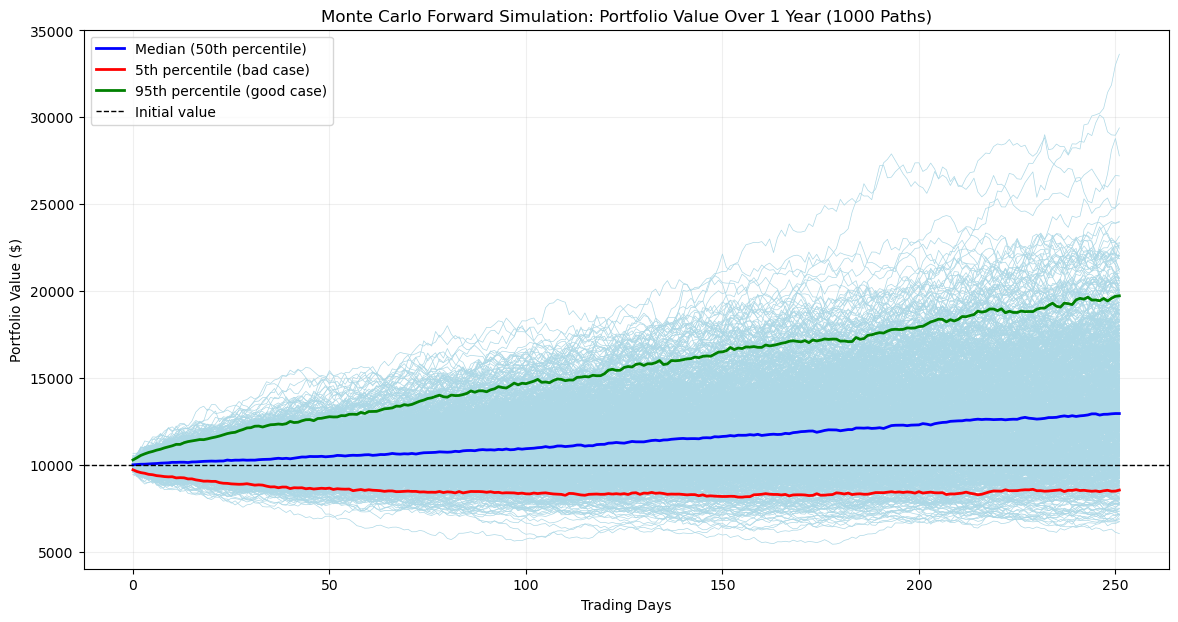

In [28]:
#Plot

plt.figure(figsize=(14,7))

plt.plot(simulation_results,color="lightblue",alpha=1,linewidth=0.5)

plt.plot(np.percentile(simulation_results,50,axis=1),color="blue",linewidth=2,label='Median (50th percentile)')
plt.plot(np.percentile(simulation_results,5,axis=1),color="red",linewidth=2,label="5th percentile (bad case)")
plt.plot(np.percentile(simulation_results,95,axis=1),color="green",linewidth=2,label="95th percentile (good case)")

plt.axhline(y=initial_portfolio_value,color='black',linestyle="--",linewidth=1,label="Initial value")

plt.title("Monte Carlo Forward Simulation: Portfolio Value Over 1 Year (1000 Paths)")
plt.xlabel("Trading Days")
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True,alpha=0.2)
plt.show()

In [29]:
final_values = simulation_results[-1, :]  # last day of all simulations

print(f"Starting portfolio value:        ${initial_portfolio_value:,.0f}")
print(f"Median final value:              ${np.median(final_values):,.0f}")
print(f"Mean final value:                ${np.mean(final_values):,.0f}")
print(f"5th percentile (bad scenario):   ${np.percentile(final_values, 5):,.0f}")
print(f"95th percentile (good scenario): ${np.percentile(final_values, 95):,.0f}")
print(f"Probability of loss:             {(final_values < initial_portfolio_value).mean():.2%}")

Starting portfolio value:        $10,000
Median final value:              $12,961
Mean final value:                $13,383
5th percentile (bad scenario):   $8,558
95th percentile (good scenario): $19,732
Probability of loss:             17.30%
